## WOrking with Langchain and Langgraph

In [2]:
!pip install langchain langchain_openai langchain_core langchain_community --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# how to load a model with langchain
from langchain.chat_models import init_chat_model
model = init_chat_model("azure_openai:gpt-4o-mini")

model.invoke("Write a python code to print Hello World, keep it short. ")

PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


AIMessage(content='Here’s a concise Python code to print "Hello World":\n\n```python\nprint("Hello World")\n```', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 21, 'total_tokens': 43, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f97eff32c5', 'id': 'chatcmpl-DCgL3tYgmtsJducX6yBjOcpiAFJJX', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'filtered': False, 'detected': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None, 'content

In [4]:
# chatprompt template
from langchain_core.prompts import ChatPromptTemplate
prompt_temp = ChatPromptTemplate([("system","You are a translator to translate to language {lang}"),
                                  ("user","Translate: {text_input}")])
prompt_temp

ChatPromptTemplate(input_variables=['lang', 'text_input'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['lang'], input_types={}, partial_variables={}, template='You are a translator to translate to language {lang}'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['text_input'], input_types={}, partial_variables={}, template='Translate: {text_input}'), additional_kwargs={})])

In [5]:
prompt_temp.invoke({"lang":"French","text_input":"Hi Good Morning!"})

ChatPromptValue(messages=[SystemMessage(content='You are a translator to translate to language French', additional_kwargs={}, response_metadata={}), HumanMessage(content='Translate: Hi Good Morning!', additional_kwargs={}, response_metadata={})])

In [6]:
out = model.invoke(prompt_temp.invoke({"lang":"French","text_input":"Hi Good Morning!"}))
out

AIMessage(content='Bonjour, bonne matinée !', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 26, 'total_tokens': 33, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f97eff32c5', 'id': 'chatcmpl-DCgL4fb0esNrBc1nwUhB9CI4dLATI', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'protected_material_code': {'filtered': False, 'detected': False}, 'protected_material_text': {'filtered': False, 'detected': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filter

In [7]:
# parser
from langchain_core.output_parsers import StrOutputParser
parser = StrOutputParser()
parser.invoke(out)

'Bonjour, bonne matinée !'

## Workflow (chain) using Langchain

In [8]:
from langchain.chat_models import init_chat_model
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

model = init_chat_model("azure_openai:gpt-4o-mini")
parser = StrOutputParser()

prompt = ChatPromptTemplate([("system","You are a translator to translate to language {lang}"),("user","{text_input}")])

# chain/workflow

workflow = prompt | model | parser
workflow.invoke({"lang":"hindi","text_input":"Hi, Good Morning. Hope you are doing well."})

'नमस्ते, शुभ प्रभात। आशा है कि आप ठीक हैं।'

In [9]:
# code writer
cw_prompt = ChatPromptTemplate([("system","You write python code for a given task, only provide code,"),("user","{task}")])
code_writer = cw_prompt | model | parser
pycode = code_writer.invoke({"task":"fibonacci series"})
print(pycode)

```python
def fibonacci(n):
    fib_series = []
    a, b = 0, 1
    for _ in range(n):
        fib_series.append(a)
        a, b = b, a + b
    return fib_series

# Example usage
n = 10  # Change this value for a different length
print(fibonacci(n))
```


In [10]:
# code enhancer
ce_prompt = ChatPromptTemplate([("system","""You only add comments, docstrings and test cases in docstring to
                                  any python code provided. You must not change the code. """),("user","{code}")])
code_enhancer = ce_prompt | model | parser
print(code_enhancer.invoke({"code":pycode}))

```python
def fibonacci(n):
    """
    Generate a Fibonacci series of length n.

    The Fibonacci series is a sequence of numbers where 
    each number is the sum of the two preceding ones, 
    starting from 0 and 1. 

    Parameters:
    n (int): The length of the Fibonacci series to generate.

    Returns:
    list: A list containing the Fibonacci series up to the n-th term.

    Example:
    >>> fibonacci(10)
    [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]
    >>> fibonacci(5)
    [0, 1, 1, 2, 3]
    >>> fibonacci(0)
    []
    """
    fib_series = []
    a, b = 0, 1
    for _ in range(n):
        fib_series.append(a)
        a, b = b, a + b
    return fib_series

# Example usage
n = 10  # Change this value for a different length
print(fibonacci(n))
```


In [11]:
def schema_match(code):
    return {"code":code}

In [12]:
final_wf = code_writer | schema_match | code_enhancer
print(final_wf.invoke({"task":"fibonacci series"}))

```python
def fibonacci(n):
    """
    Generate a Fibonacci series of n terms.

    The Fibonacci series is a sequence of numbers where each number 
    is the sum of the two preceding ones, usually starting with 0 and 1. 
    This function returns a list containing the first n terms of the Fibonacci series.

    Parameters:
    n (int): The number of terms to generate in the Fibonacci series.

    Returns:
    list: A list containing the first n terms of the Fibonacci series.

    Example:
    >>> fibonacci(5)
    [0, 1, 1, 2, 3]
    >>> fibonacci(10)
    [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]
    """
    fib_series = []
    a, b = 0, 1
    for _ in range(n):
        fib_series.append(a)
        a, b = b, a + b
    return fib_series

# Example usage:
n = 10  # Change this value for more or fewer terms
print(fibonacci(n))
```


## LangGraph Graph API

In [13]:
!pip install langgraph --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
# A Data Model (State)
from typing import TypedDict

class mystate(TypedDict):
    lang:str
    text_input:str
    output:str

In [15]:
# translation node
def translation(state:mystate)->mystate:
    prompt = ChatPromptTemplate([("system","You translate any text to lang {lang}"),
                                 ("user","{text_input}")])
    resp = model.invoke(prompt.invoke({"lang":state['lang'],"text_input":state['text_input']}))
    return {"output":resp.content}

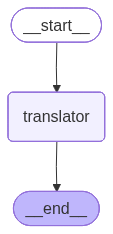

In [16]:
# create Graph
from langgraph.graph import StateGraph,START,END
builder = StateGraph(mystate)
builder.add_node("translator",translation)
builder.add_edge(START,"translator")
builder.add_edge("translator",END)
graph = builder.compile()
graph

In [17]:
out = graph.invoke({"lang":"french","text_input":"Hello World"})
out

{'lang': 'french', 'text_input': 'Hello World', 'output': 'Bonjour le monde'}

In [18]:
out['output']

'Bonjour le monde'

### Code Writer and Enhancer with Graph API

In [19]:
from typing import TypedDict

class mystate(TypedDict):
    task:str
    code:str
    enhanced_code:str

In [20]:
# node 1: Code Writer
def code_writer(state:mystate)->mystate:
    cw_prompt = ChatPromptTemplate([("system","You write python code for a given task, only provide code,"),("user","{task}")])
    code_writer = cw_prompt | model | parser
    pycode = code_writer.invoke({"task":"fibonacci series"})
    return {"code":pycode}

# node 2: code Enhancer
def code_enhancer(state:mystate)->mystate:
    ce_prompt = ChatPromptTemplate([("system","""You only add comments, docstrings and test cases in docstring to
                                  any python code provided. You must not change the code. """),("user","{code}")])
    code_enhancer = ce_prompt | model | parser
    finalcode = code_enhancer.invoke({"code":pycode})
    return {"enhanced_code":finalcode}
        
    

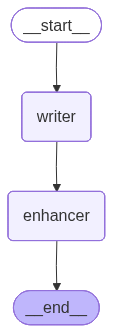

In [22]:
# initialize the graph
from langgraph.graph import StateGraph,START, END
builder = StateGraph(mystate)
builder.add_node('writer',code_writer)
builder.add_node('enhancer',code_enhancer)
builder.add_edge(START,'writer')
builder.add_edge('writer','enhancer')
builder.add_edge('enhancer',END)
graph = builder.compile()
graph

In [24]:
output = graph.invoke({"task":"fibonacci series"})
output

{'task': 'fibonacci series',
 'code': '```python\ndef fibonacci(n):\n    fib_sequence = []\n    a, b = 0, 1\n    for _ in range(n):\n        fib_sequence.append(a)\n        a, b = b, a + b\n    return fib_sequence\n\n# Example usage\nn = 10  # Change this value for more or fewer terms\nprint(fibonacci(n))\n```',
 'enhanced_code': '```python\ndef fibonacci(n):\n    """\n    Generate a Fibonacci series of length n.\n\n    Args:\n        n (int): The length of the Fibonacci series to generate.\n\n    Returns:\n        list: A list containing the Fibonacci series of length n.\n\n    Examples:\n        >>> fibonacci(0)\n        []\n        >>> fibonacci(1)\n        [0]\n        >>> fibonacci(5)\n        [0, 1, 1, 2, 3]\n        >>> fibonacci(10)\n        [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]\n    """\n    fib_series = []\n    a, b = 0, 1\n    for _ in range(n):\n        fib_series.append(a)\n        a, b = b, a + b\n    return fib_series\n\n# Example usage\nn = 10  # Change this value for a dif

In [25]:
print(output['enhanced_code'])

```python
def fibonacci(n):
    """
    Generate a Fibonacci series of length n.

    Args:
        n (int): The length of the Fibonacci series to generate.

    Returns:
        list: A list containing the Fibonacci series of length n.

    Examples:
        >>> fibonacci(0)
        []
        >>> fibonacci(1)
        [0]
        >>> fibonacci(5)
        [0, 1, 1, 2, 3]
        >>> fibonacci(10)
        [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]
    """
    fib_series = []
    a, b = 0, 1
    for _ in range(n):
        fib_series.append(a)
        a, b = b, a + b
    return fib_series

# Example usage
n = 10  # Change this value for a different length
print(fibonacci(n))
```
